# Preparación de los datos 

## Selecciona el conjunto de datos a utilizar.

Las estaciones que se decidieron utilizar son:

* Noroeste 2 - García
* Noroeste 3 - García
* Suroeste - Santa Catarina
* Este - Pesquería
* Sureste 3 - Cadereyta

In [2]:
import pandas as pd

In [3]:
NO2 = pd.read_csv('../data_estaciones/BD_NO2.csv') # García
NO3 = pd.read_csv('../data_estaciones/BD_NO3.csv') # García
SO = pd.read_csv('../data_estaciones/BD_SO.csv') # Santa Catarina
NE3 = pd.read_csv('../data_estaciones/BD_NE3.csv') # Pesquería
SE3 = pd.read_csv('../data_estaciones/BD_SE3.csv') # Cadereyta

Se excluye la variable Nox porque es una combinación lineal de las otras dos.

In [ ]:
# Excluir variable NOX

NO2 = NO2.drop(columns=['NOX'])
NO3 = NO3.drop(columns=['NOX'])
SO = SO.drop(columns=['NOX'])
NE3 = NE3.drop(columns=['NOX'])
SE3 = SE3.drop(columns=['NOX'])

Las columnas objetivo serán las variables de contaminantes, estas son: PM10, PM2.5, 03, SO2, NO2, CO, NO

## Limpieza de datos

No deberían existir horas duplicadas, por lo que la cantidad de horas diferentes debe coincidir con la cantidad total de datos.

In [10]:
estaciones = [NO2, NO3, SO, NE3, SE3]

for i, estacion in enumerate(estaciones):
    print('Estacion', i)
    if estacion['date'].nunique() != len(estacion):
        print('La estacion', i, 'tiene fechas duplicadas')
    else:
        print('La estacion', i, 'no tiene fechas duplicadas')

Estacion 0
La estacion 0 no tiene fechas duplicadas
Estacion 1
La estacion 1 no tiene fechas duplicadas
Estacion 2
La estacion 2 no tiene fechas duplicadas
Estacion 3
La estacion 3 no tiene fechas duplicadas
Estacion 4
La estacion 4 no tiene fechas duplicadas


No parece haber datos duplicados.

In [11]:
columnas_numericas = list(NO2.columns)
columnas_numericas = [col for col in columnas_numericas if col != 'date' and col != 'anio']

In [13]:
import matplotlib.pyplot as plt

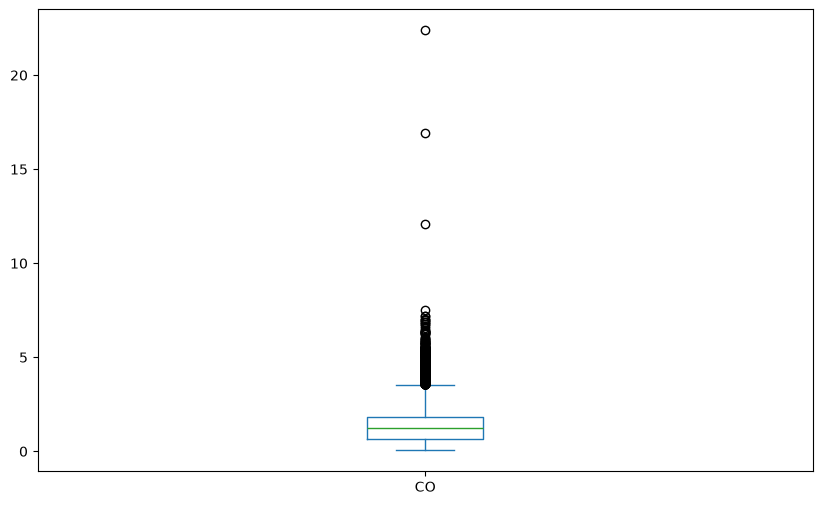

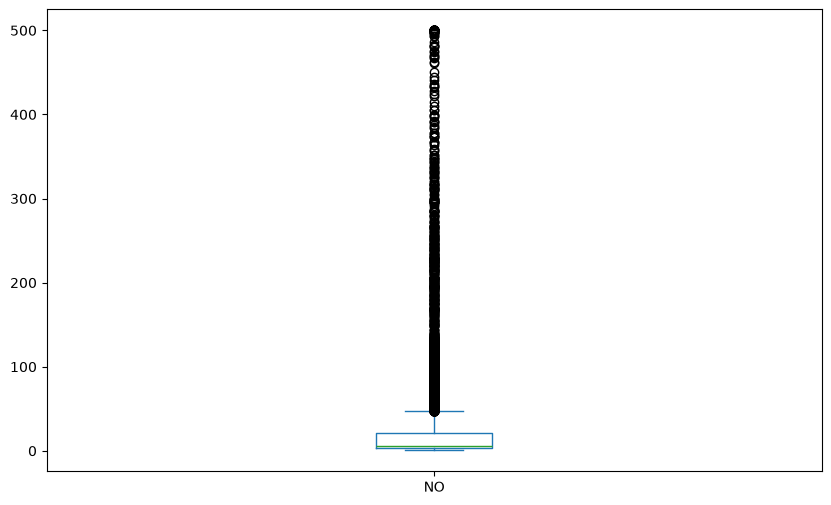

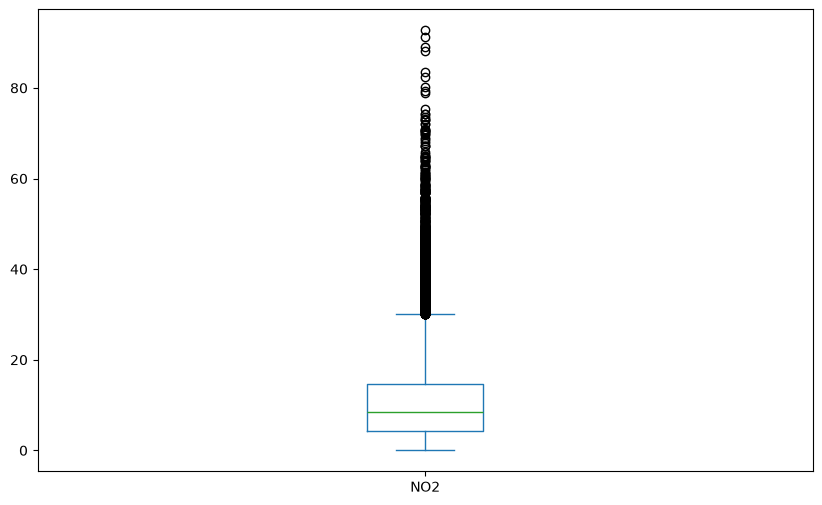

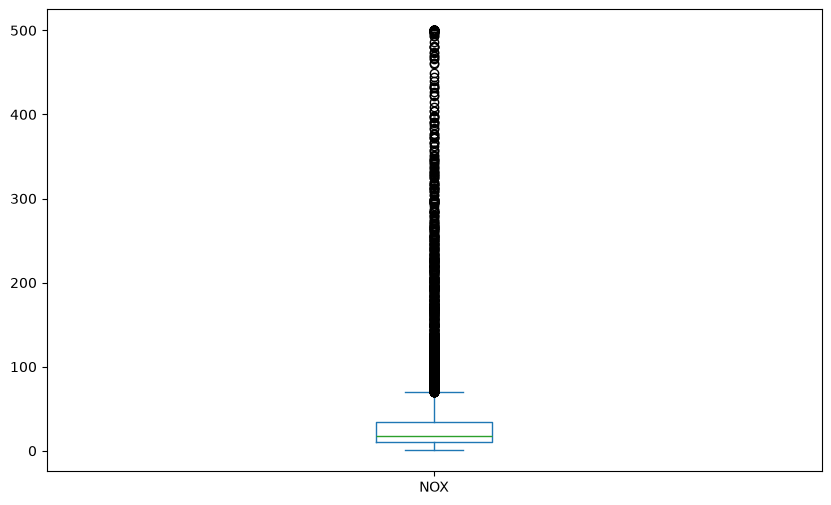

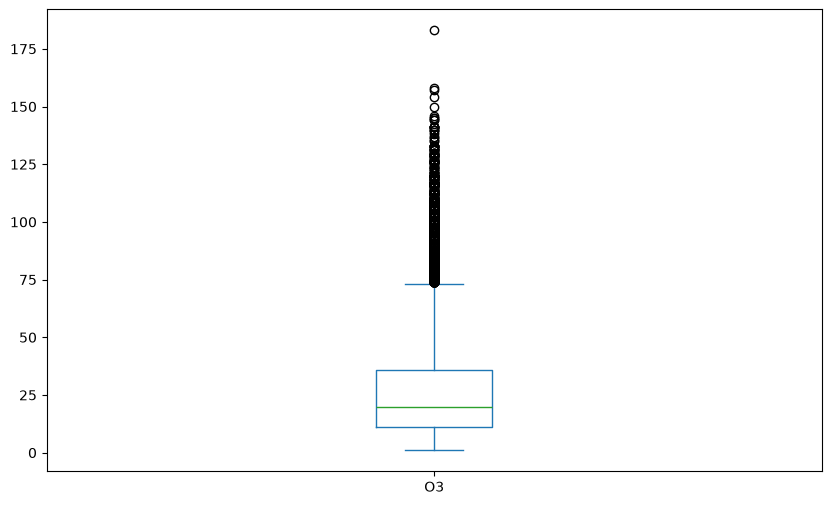

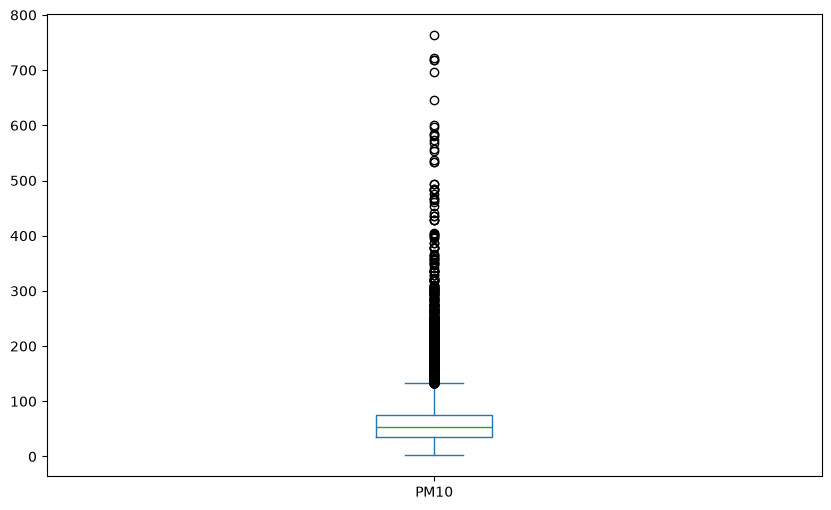

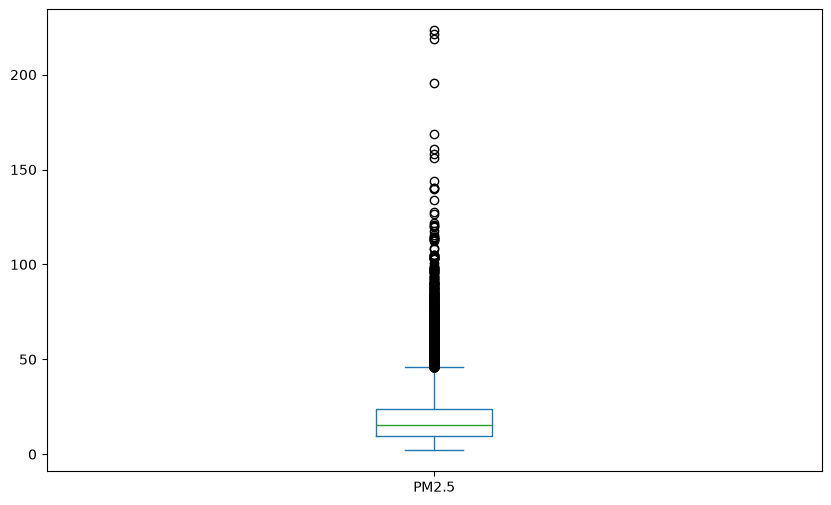

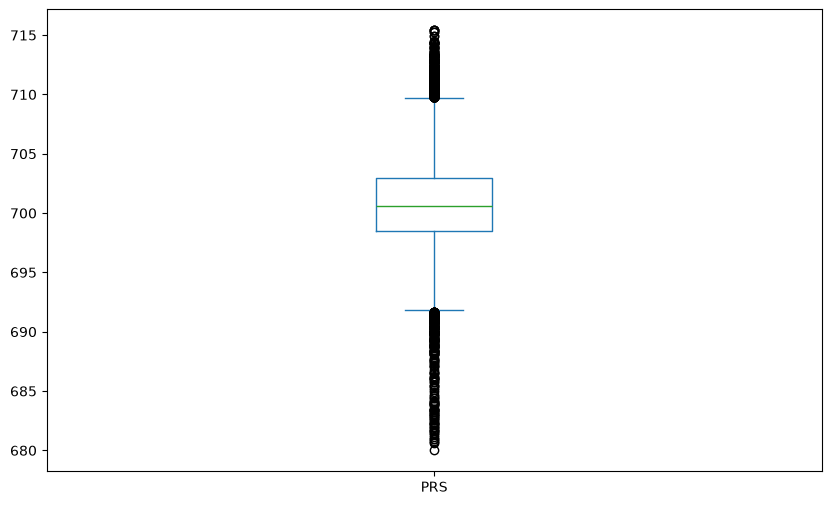

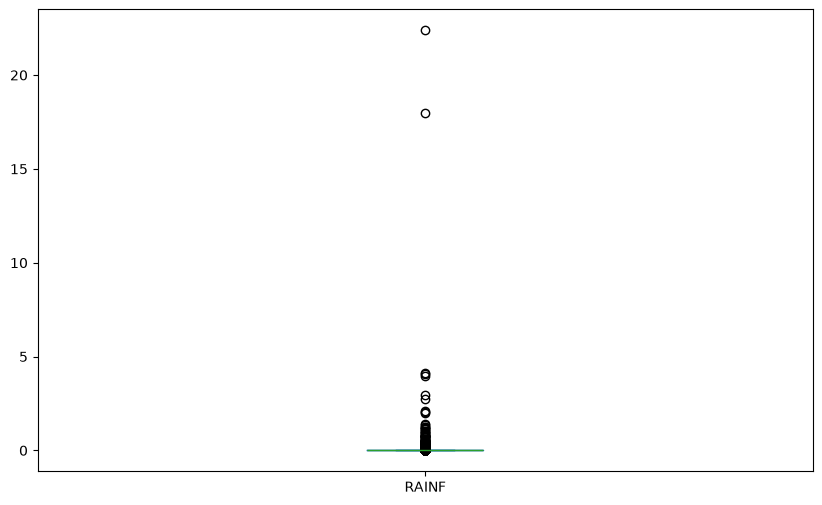

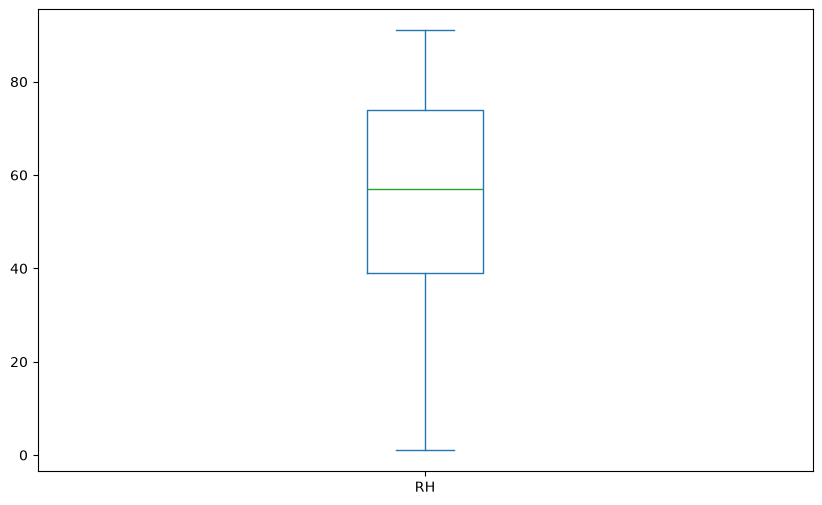

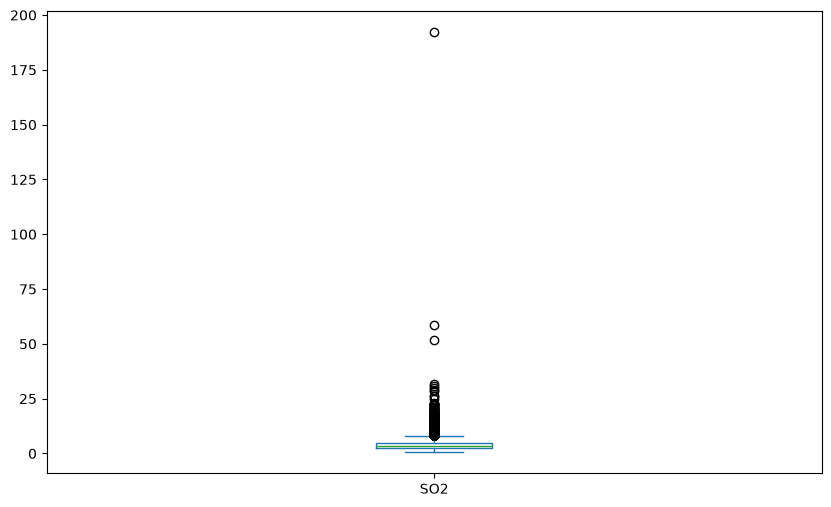

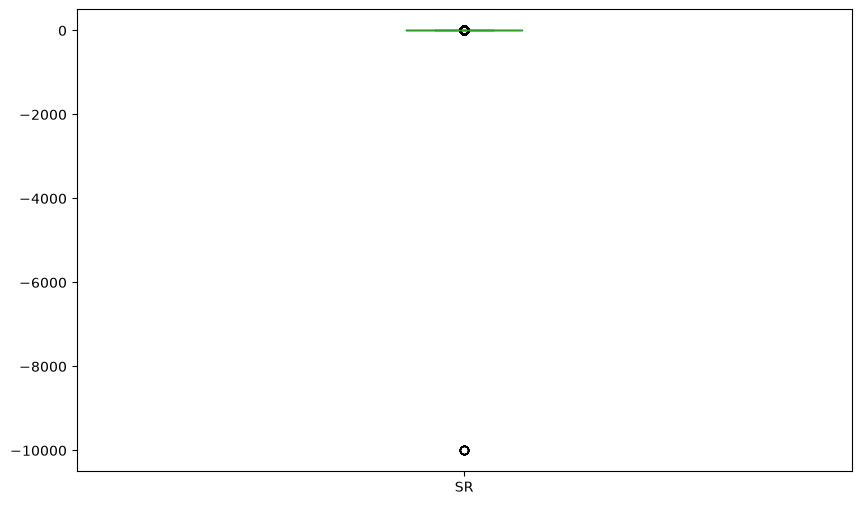

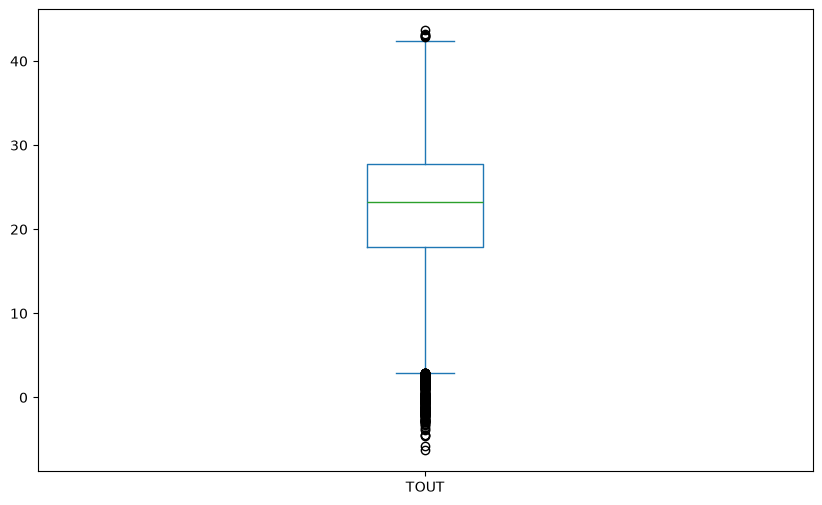

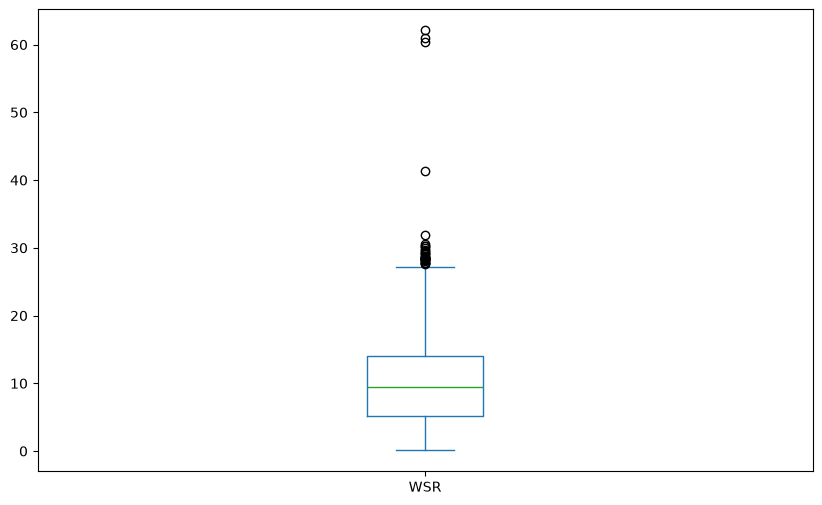

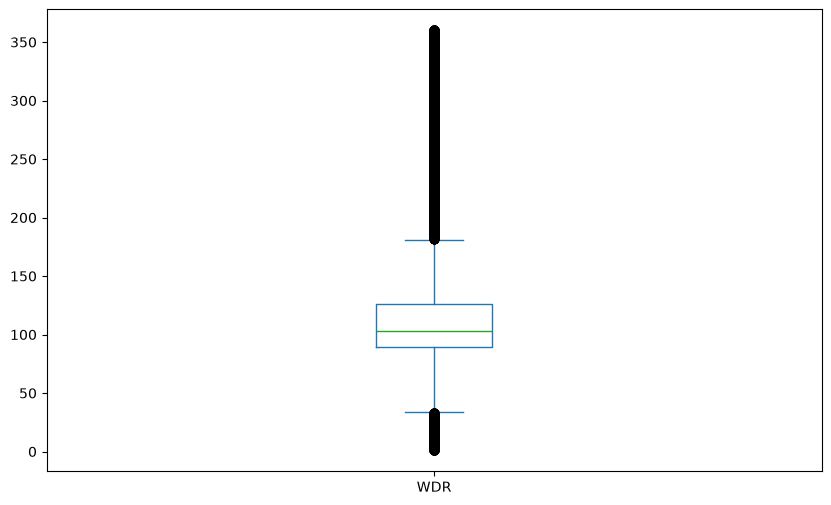

In [16]:
for col in columnas_numericas:
    plt.figure(figsize=(10,6))
    NO2[col].plot(kind='box')
    plt.show()

Parece que hay datos completamente erróneos que se deben de eliminar basándonos en los valores posibles proporcionados por SIMA. 

In [ ]:
# Rangos validos segun SIMA. Los valores fuera de estos limites se reemplazan por NaN.
rangos_validos = {
    'PM10': (0, 999),
    'PM2.5': (0, 999),
    'O3': (0, 185),
    'NO': (0, 500),
    'NO2': (0, 200),
    'SO2': (0, 405),
    'CO': (0, 20),
    'RH': (0, 100),
    'WSR': (0, 75),
    'TOUT': (-6.5, 45.5),
    'SR': (0, 1.26),
    'WDR': (0, 360),
    'RAINF': (0, 80)
}

for nombre, estacion in zip(['NO2', 'NO3', 'SO', 'NE3', 'SE3'], estaciones):
    valores_eliminados = 0

    for columna, (minimo, maximo) in rangos_validos.items():
        if columna in estacion.columns:
            valores = pd.to_numeric(estacion[columna], errors='coerce')
            fuera_de_rango = (valores < minimo) | (valores > maximo)
            valores_eliminados += fuera_de_rango.sum()
            estacion.loc[fuera_de_rango, columna] = pd.NA

    print(f'{nombre}: {valores_eliminados} valores fuera de rango reemplazados por NaN')

NO2: 14 valores fuera de rango reemplazados por NaN
NO3: 160 valores fuera de rango reemplazados por NaN
SO: 228 valores fuera de rango reemplazados por NaN
NE3: 44 valores fuera de rango reemplazados por NaN
SE3: 6 valores fuera de rango reemplazados por NaN


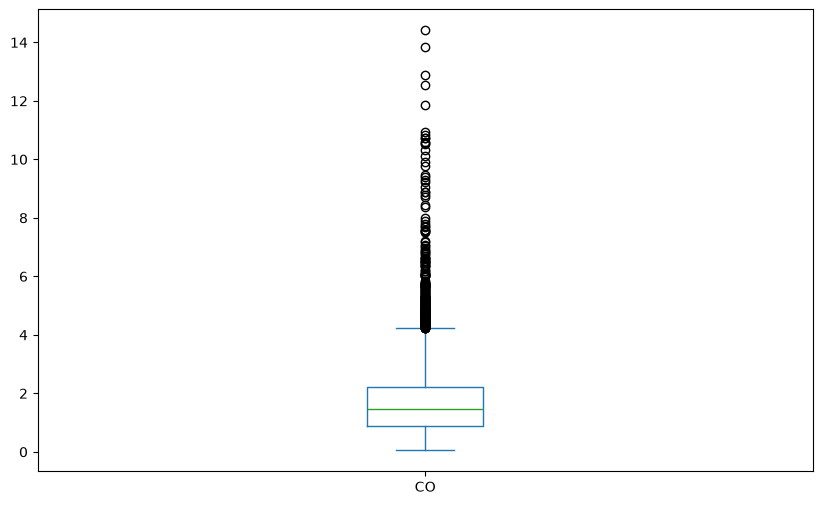

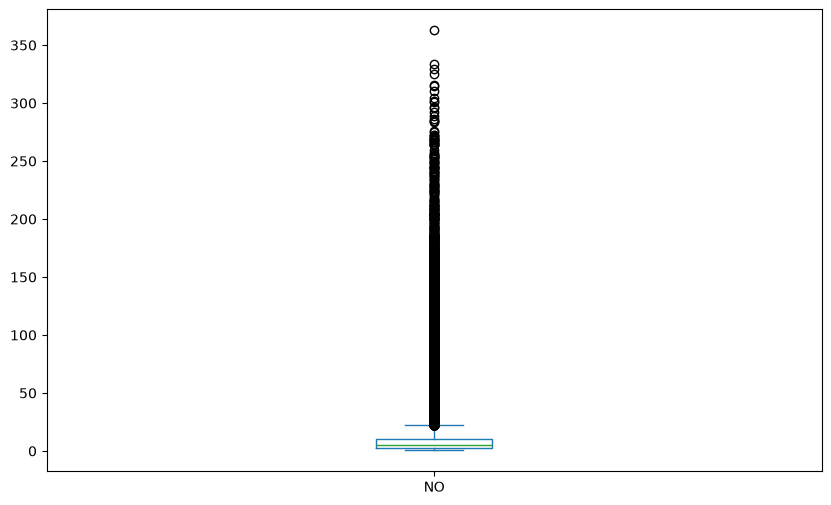

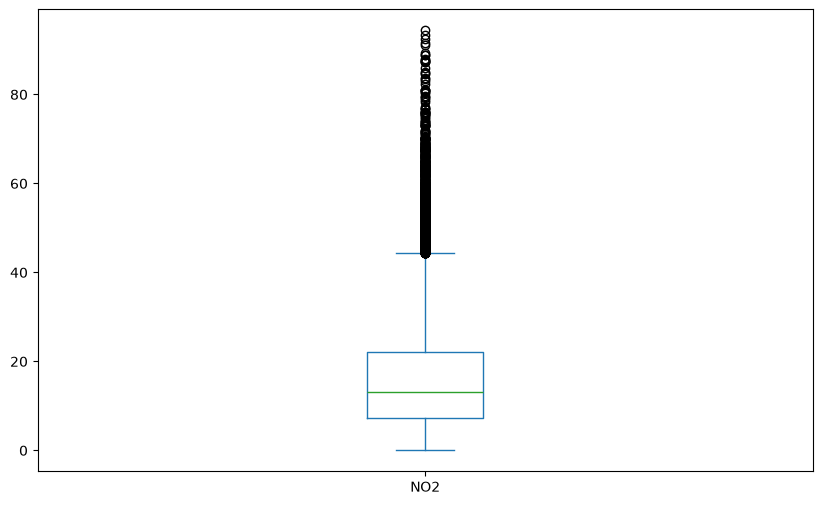

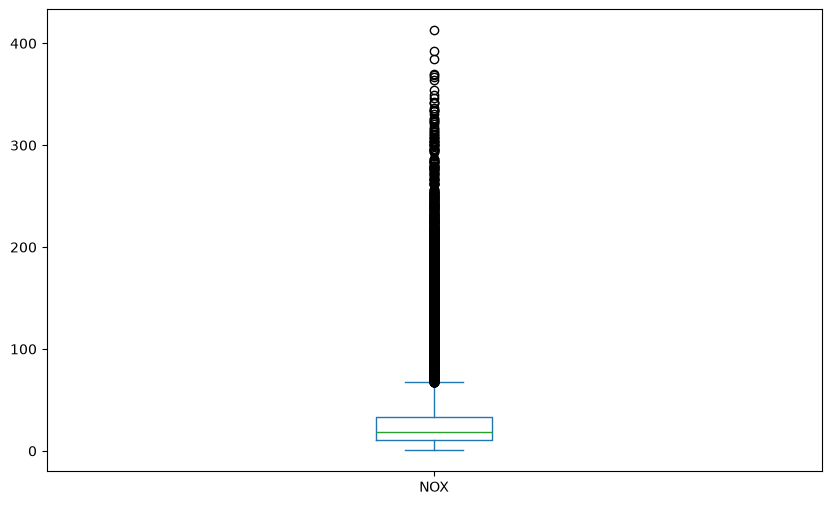

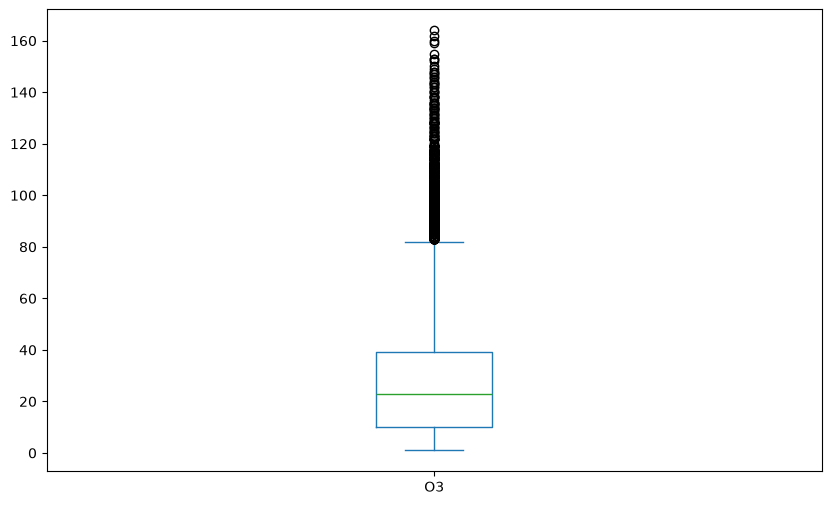

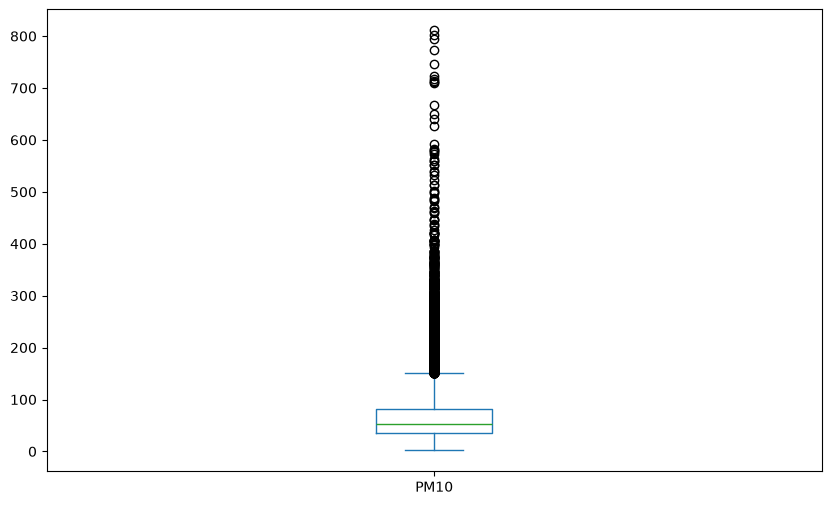

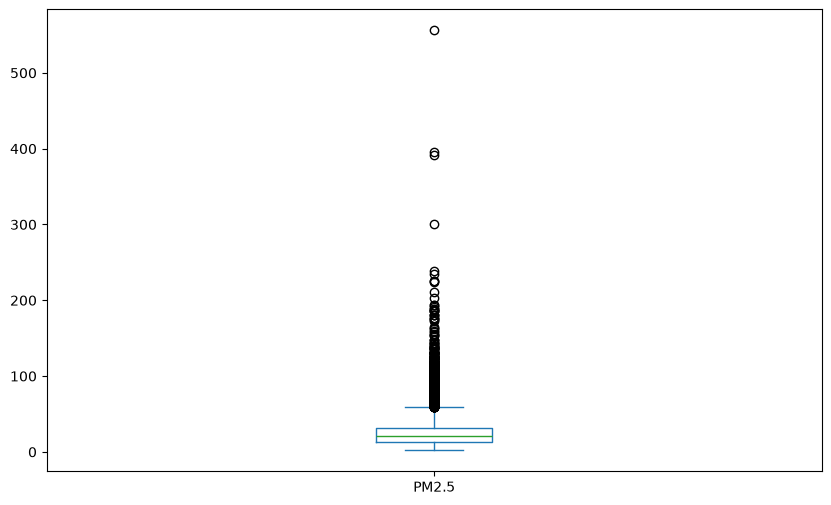

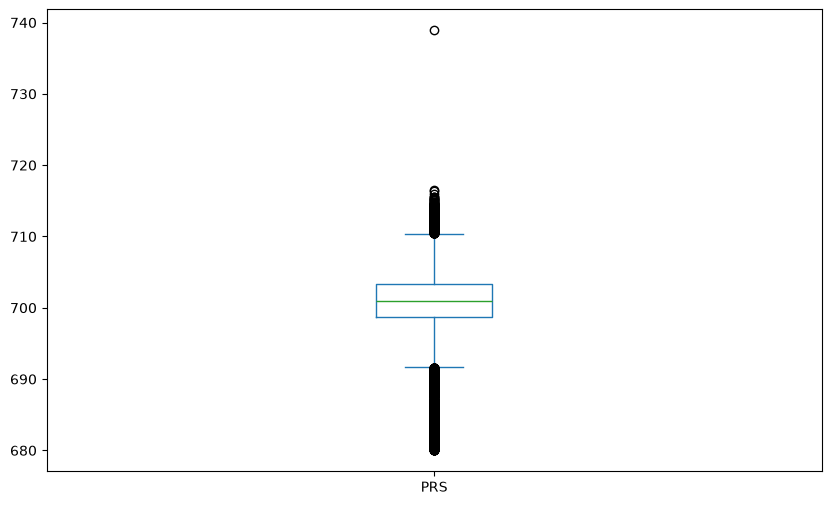

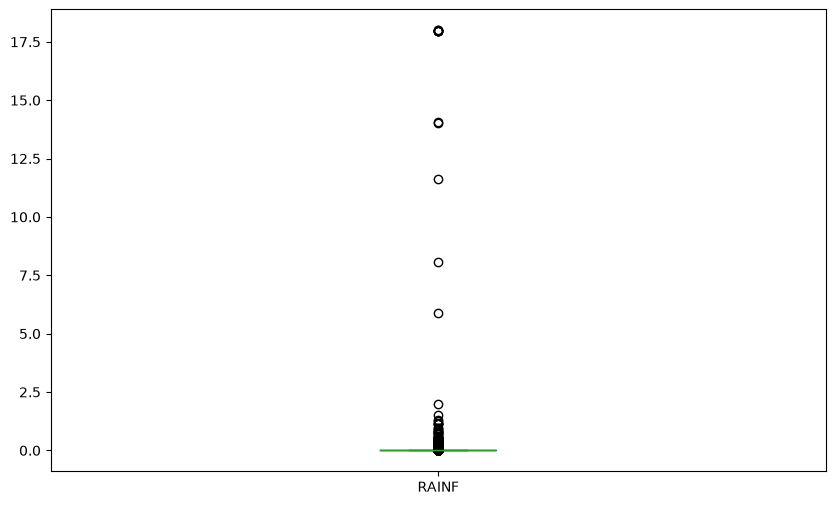

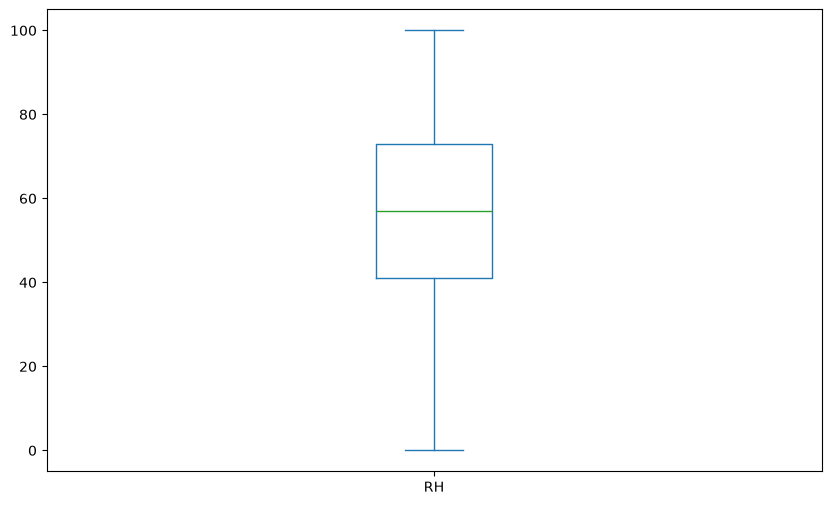

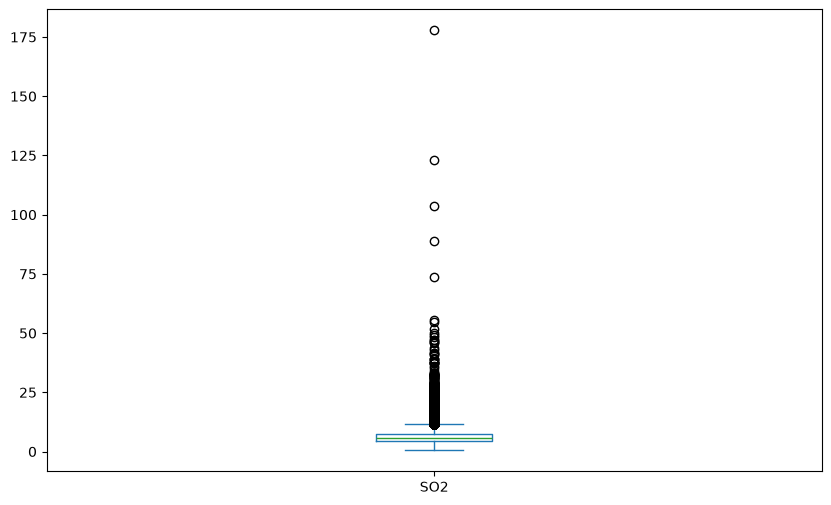

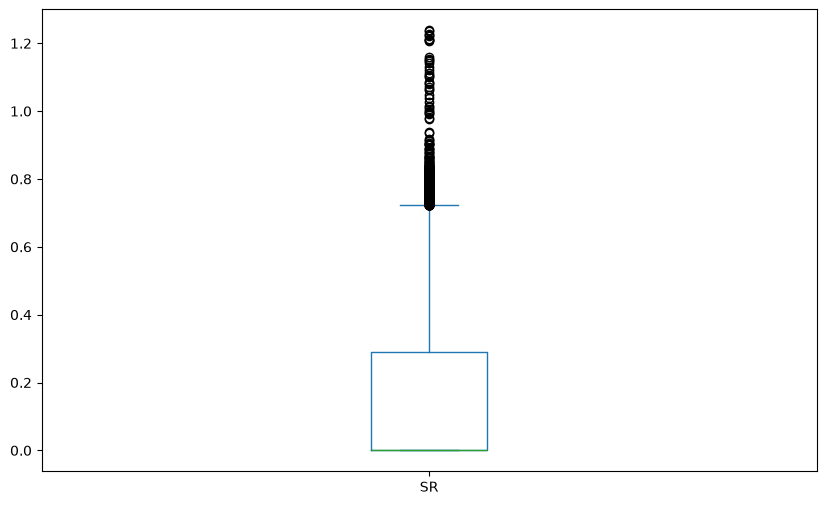

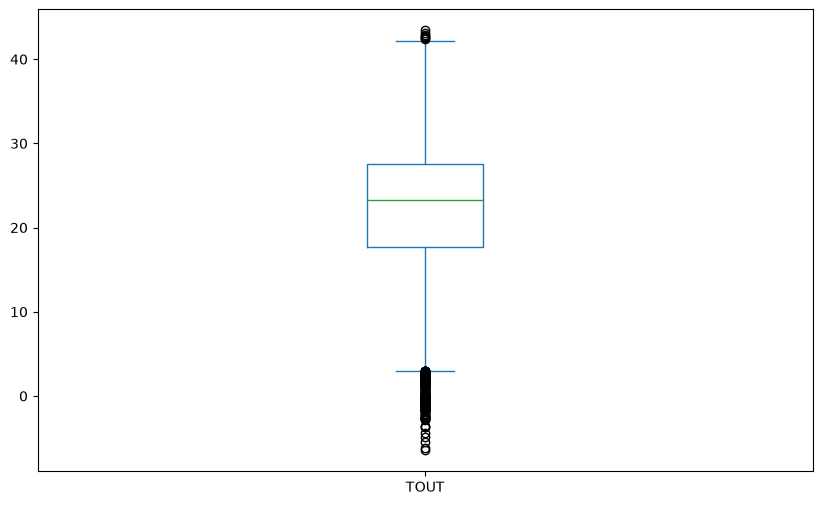

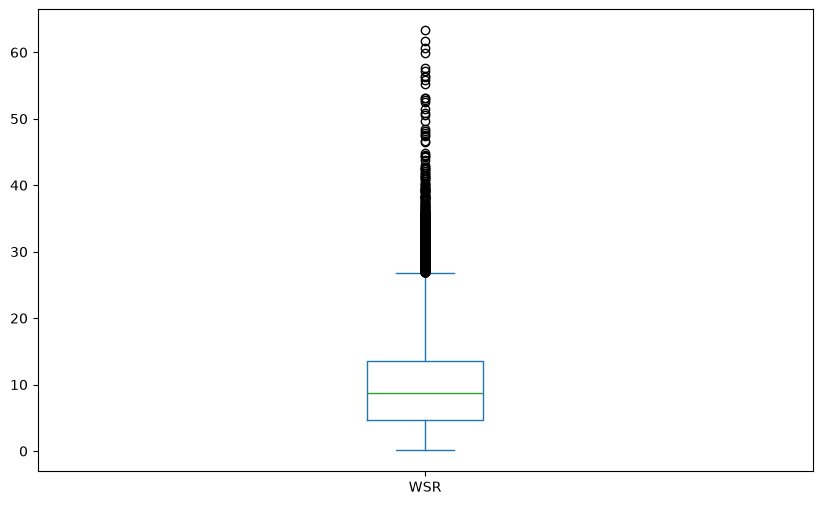

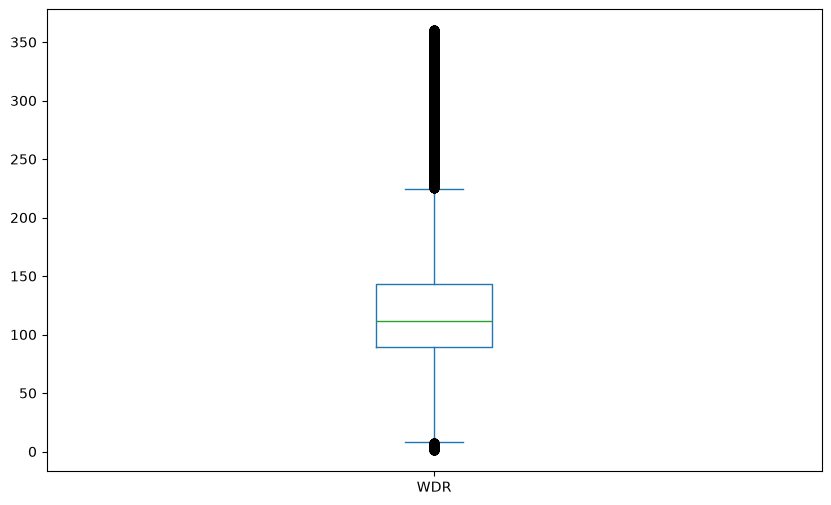

In [18]:
for col in columnas_numericas:
    plt.figure(figsize=(10,6))
    SO[col].plot(kind='box')
    plt.show()

Los datos están extremadamente sesgados, sin embargo, los valores atípicos son importantes dada la naturaleza del fenómeno y no se pueden eliminar sencillamente. Puede que una transformación logarítmica sea adecuada. 

Después de la eliminación de datos erróneos, revisaremos la proporción de datos atípicos.

In [23]:
# Proporción de valores faltantes por estación y variable y total

for nombre, estacion in zip(['NO2', 'NO3', 'SO', 'NE3', 'SE3'], estaciones):
    total_filas = len(estacion)
    print(f'Proporción de valores faltantes en {nombre}:')
    total = 0
    for columna in columnas_numericas:
        if columna in estacion.columns:
            num_faltantes = estacion[columna].isna().sum()
            total += num_faltantes
            proporcion_faltantes = num_faltantes / total_filas
            print(f'  {columna}: {proporcion_faltantes:.2%}')  
    print(f'  Total: {total / (total_filas * len(columnas_numericas)):.2%}\n')

Proporción de valores faltantes en NO2:
  CO: 2.90%
  NO: 11.15%
  NO2: 15.90%
  NOX: 10.16%
  O3: 7.09%
  PM10: 2.86%
  PM2.5: 14.87%
  PRS: 4.10%
  RAINF: 1.86%
  RH: 4.85%
  SO2: 11.70%
  SR: 20.22%
  TOUT: 2.59%
  WSR: 4.21%
  WDR: 7.65%
  Total: 8.14%

Proporción de valores faltantes en NO3:
  CO: 11.68%
  NO: 30.93%
  NO2: 30.81%
  NOX: 30.05%
  O3: 8.53%
  PM10: 4.82%
  PM2.5: 89.68%
  PRS: 1.19%
  RAINF: 1.12%
  RH: 35.54%
  SO2: 6.90%
  SR: 1.36%
  TOUT: 1.17%
  WSR: 10.25%
  WDR: 2.05%
  Total: 17.74%

Proporción de valores faltantes en SO:
  CO: 14.08%
  NO: 9.64%
  NO2: 11.75%
  NOX: 12.81%
  O3: 10.32%
  PM10: 3.31%
  PM2.5: 10.32%
  PRS: 6.87%
  RAINF: 3.60%
  RH: 6.97%
  SO2: 7.70%
  SR: 2.91%
  TOUT: 4.61%
  WSR: 4.32%
  WDR: 8.26%
  Total: 7.83%

Proporción de valores faltantes en NE3:
  CO: 6.38%
  NO: 7.61%
  NO2: 7.44%
  NOX: 7.01%
  O3: 5.56%
  PM10: 6.01%
  PM2.5: 100.00%
  PRS: 4.94%
  RAINF: 3.82%
  RH: 3.96%
  SO2: 40.08%
  SR: 12.21%
  TOUT: 4.49%
  WSR: 6.47%

Existe una gran cantidad de valores faltantes en algunas estaciones, más adelante puede que sea conveniente limitar las estaciones o las variables para solo estudiar aquellas con pocos valores faltantes.

In [25]:
for col in columnas_numericas:
    descripcion = []
    for nombre, estacion in zip(['NO2', 'NO3', 'SO', 'NE3', 'SE3'], estaciones):
        descripcion.append({
            'archivo': nombre,
            'min': estacion[col].min(),
            'max': estacion[col].max(),
            'mean': estacion[col].mean(),
            'std': estacion[col].std(),
            'count': estacion[col].count(),
            'nulls': estacion[col].isnull().sum(),
            '% nulls': (estacion[col].isnull().sum() / len(estacion)) * 100
        })
    descripcion_df = pd.DataFrame(descripcion)
    print(f"\nDescripción de la variable '{col}':")
    display(descripcion_df)


Descripción de la variable 'CO':


,archivo,min,max,mean,std,count,nulls,% nulls
0,NO2,0.05,16.930,1.342052,0.837438,46781,1398,2.901679
1,NO3,0.05,6.000,1.475682,0.827713,19966,2640,11.678315
2,SO,0.05,14.410,1.587178,0.879355,41277,6764,14.079640
3,NE3,0.05,13.422,0.445064,0.330955,36866,2512,6.379197
4,SE3,0.05,17.710,1.301061,0.761693,44810,3368,6.990743



Descripción de la variable 'NO':


,archivo,min,max,mean,std,count,nulls,% nulls
0,NO2,0.5,500.0,17.499675,34.056517,42808,5371,11.148011
1,NO3,0.5,500.0,13.110861,25.779152,15615,6991,30.925418
2,SO,0.5,362.7,13.380712,26.983190,43408,4633,9.643846
3,NE3,1.3,313.5,13.792900,12.992409,36382,2996,7.608309
4,SE3,0.5,370.8,8.797167,16.674328,46315,1863,3.866910



Descripción de la variable 'NO2':


...

,archivo,min,max,mean,std,count,nulls,% nulls
0,NO2,-6.30,43.65,22.533443,7.295930,46933,1246,2.586189
1,NO3,-3.40,43.95,22.986067,7.568607,22341,265,1.172255
2,SO,-6.46,43.42,22.404992,7.108241,45825,2216,4.612727
3,NE3,-4.10,44.10,23.237125,7.773891,37610,1768,4.489817
4,SE3,-3.22,42.93,23.464703,7.362374,47131,1047,2.173191



Descripción de la variable 'WSR':


,archivo,min,max,mean,std,count,nulls,% nulls
0,NO2,0.1,62.1,9.759525,5.385213,46153,2026,4.205152
1,NO3,0.1,73.1,10.578615,7.457120,20290,2316,10.245068
2,SO,0.1,63.3,9.798605,6.516979,45964,2077,4.323390
3,NE3,0.5,34.4,8.105802,5.459845,36831,2547,6.468079
4,SE3,0.1,42.0,6.678709,4.378029,46889,1289,2.675495



Descripción de la variable 'WDR':


,archivo,min,max,mean,std,count,nulls,% nulls
0,NO2,1.0,360.0,128.868072,86.935347,44491,3688,7.654787
1,NO3,1.0,360.0,95.064312,90.542553,22142,464,2.052552
2,SO,1.0,360.0,129.482371,83.621472,44074,3967,8.257530
3,NE3,1.0,360.0,154.719697,92.663346,37807,1571,3.989537
4,SE3,1.0,360.0,163.363897,95.358210,47104,1074,2.229233


## Interpretacion de los estadisticos

- **CO:** Las concentraciones promedio son bajas, entre 0.45 y 1.59, con dispersion moderada y algunos valores altos que alcanzan hasta 17.71.
- **NO:** Presenta promedios relativamente bajos, entre 8.80 y 17.50, pero una dispersion considerable y maximos elevados, lo que indica una distribucion sesgada a la derecha.
- **NO2:** Sus promedios se encuentran entre 9.74 y 15.77, con dispersion moderada; los valores observados llegan hasta 94.4.
- **NOX:** Registra promedios de 19.35 a 29.62 y una dispersion amplia, aunque esta variable no debe analizarse porque es una combinacion lineal de NO y NO2.
- **O3:** Los promedios son muy similares entre estaciones, aproximadamente de 25.15 a 27.74, con variabilidad moderada y maximos cercanos al limite superior permitido.
- **PM10:** Presenta promedios de 40.14 a 66.49 y una dispersion importante, con valores maximos altos que reflejan episodios de concentracion elevada.
- **PM2.5:** Los promedios disponibles varian entre 7.60 y 25.52 y muestran dispersion moderada; en algunas estaciones se observan valores maximos considerablemente mayores que el promedio.
- **PRS:** Es una variable muy estable, con promedios entre 700.83 y 731.18 y desviaciones estandar cercanas a 4.
- **RAINF:** La lluvia registra promedios practicamente nulos y desviaciones muy pequenas, aunque presenta algunos episodios puntuales de precipitacion.
- **RH:** La humedad relativa tiene promedios cercanos a 55-61% y dispersion moderada, con valores que cubren casi todo el intervalo de 0 a 100%.
- **SO2:** Sus promedios son bajos, entre 3.88 y 7.01, pero la dispersion aumenta en algunas estaciones debido a valores maximos elevados.
- **SR:** La radiacion solar presenta promedios bajos, entre 0.12 y 0.19, y una dispersion relativamente grande respecto a su media, con valores entre 0 y 1.24.
- **TOUT:** La temperatura promedio es muy similar entre estaciones, aproximadamente de 22.40 a 23.46 grados, con dispersion moderada y rangos amplios entre valores frios y calidos.
- **WSR:** La velocidad del viento presenta promedios entre 6.68 y 10.58, con dispersion moderada y maximos que llegan hasta 73.1.
- **WDR:** La direccion del viento muestra promedios distintos entre estaciones, de 95.06 a 163.36 grados, y una dispersion alta debido a que puede recorrer practicamente todo el rango angular.